<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 1 Final v7: AI 수요 vs 가상화폐 가격변동의 하드웨어 가격 영향 비교</mark></b></span><br><br>

<b>[교수님 요구사항]</b><br>
이번 H1의 목표는 <b>AI 수요와 가상화폐 가격 변동 중 어느 쪽이 GPU/CPU/RAM 가격 변동 시계열에 더 영향을 미쳤는지 정량적으로 비교</b>하는 것이다.<br><br>

<b>[중간발표와 겹치지 않는 점]</b><br>
중간발표 H1은 <b>Crypto → GPU 관계 존재 여부</b>를 검정했다.<br>
중간발표 H3는 <b>GPU가 CPU/RAM보다 Bitcoin에 더 민감한가</b>를 검정했다.<br>
기말 H1은 이를 반복하지 않고, <mark>AI shock과 Crypto shock을 같은 모형 안에 동시에 넣어 GPU/CPU/RAM별 상대 설명력, 상대 민감도, 예측 진단을 비교</mark>한다.<br><br>

<b>[v7에서 최종 재점검 후 수정한 점]</b><br>
1. 메인 결론은 여전히 <b>Lag-window ARDL + Partial R² + Standardized sensitivity</b>에 둔다. 이것이 교수님 요구사항인 상대 영향력 비교에 가장 직접적이다.<br>
2. <b>Rolling forecast RMSE</b>는 메인 결론이 아니라 시계열 예측 진단으로 사용한다. 두 채널 모두 base보다 예측오차를 줄이지 못하면 승자를 강제로 부여하지 않는다.<br>
3. Forecast 차이도 <b>loss-difference HAC test</b>로 보조 확인한다. 단, 표본이 작으므로 p-value 하나로 결론내리지 않는다.<br>
4. BTC-KRW와 FX 통제를 동시에 쓰는 구조의 중복 가능성을 점검하기 위해 <b>FX-adjusted BTC robustness</b>를 추가한다.<br>
5. Event Study는 교수님이 말한 specific event 관점을 보여주는 <b>보조 검정</b>으로 유지한다.<br><br>

<b>[최종 H1]</b><br>
<code>FX, 자기시차, 분기 계절성을 통제한 뒤, AI shock과 Crypto shock 중 어느 쪽이 GPU/CPU/RAM 주간 로그수익률을 더 잘 설명하는가?</code><br><br>

<b>[판단 기준]</b><br>
1. <b>Partial R²</b>: 상대 채널을 통제한 뒤 추가 설명력이 더 큰 쪽<br>
2. <b>Standardized sensitivity</b>: 1표준편차 충격 기준 lag-window 계수 크기가 더 큰 쪽<br>
3. <b>Rolling forecast RMSE gain</b>: base 대비 예측오차를 실제로 줄였는지 확인하는 보조 진단<br>
4. <b>Event CAR</b>: shock week 이후 abnormal return 반응을 보여주는 보조 진단<br><br>

<b>[중요한 해석 원칙]</b><br>
결과가 갈리면 한쪽이 원인이라고 단정하지 않는다. <mark>관측된 주간 수익률 기준 상대 설명력과 민감도가 더 큰 채널</mark>로만 표현한다.
</div>

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

OUT = Path("outputs")
RES = OUT / "h1_final_v7"
PIC = Path("output_pic") / "h1_final_v7"
RES.mkdir(parents=True, exist_ok=True)
PIC.mkdir(parents=True, exist_ok=True)

RET_PATH = OUT / "ret_all_w.csv"
HW = ["GPU_ALL", "CPU_ALL", "RAM_ALL"]
NAME = {"GPU_ALL": "GPU", "CPU_ALL": "CPU", "RAM_ALL": "RAM"}
ORDER = ["GPU", "CPU", "RAM"]

FREQ = "W-SUN"
HAC_LAG = 8
Q = 0.90
B = 5000
SEED = 42
MIN_TRAIN = 52
EPS = 1e-8

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def std(s):
    return (s - s.mean()) / s.std(ddof=0)


def nm(s):
    s = re.sub(r'[\\/:*?"<>|]+', "_", str(s))
    s = re.sub(r"\s+", "_", s).strip("._ ")
    return s[:70]


def save(name):
    p = PIC / f"{nm(name)}.png"
    plt.savefig(p, dpi=200, bbox_inches="tight")
    print("saved:", p)


def fit(formula, df, hac=True):
    m = smf.ols(formula, data=df)
    if hac:
        return m.fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAG})
    return m.fit()


def wald(mod, terms):
    h = ", ".join(f"{t}=0" for t in terms)
    out = mod.f_test(h)
    return float(np.asarray(out.fvalue).ravel()[0]), float(np.asarray(out.pvalue).ravel()[0])


def pr2(full, red):
    return (full.rsquared - red.rsquared) / (1 - red.rsquared)


def lagwin(s, lags):
    x = pd.concat([s.shift(k) for k in lags], axis=1)
    return x.mean(axis=1).where(x.notna().all(axis=1))


def win(a, b, eps=EPS):
    if a > b + eps:
        return "AI"
    if b > a + eps:
        return "Crypto"
    return "Mixed"


def gain_win(ai_gain, cr_gain, eps=EPS):
    if ai_gain > cr_gain + eps and ai_gain > eps:
        return "AI"
    if cr_gain > ai_gain + eps and cr_gain > eps:
        return "Crypto"
    return "Mixed"


def loss_p(diff):
    x = np.ones(len(diff))
    m = sm.OLS(diff, x).fit(cov_type="HAC", cov_kwds={"maxlags": min(HAC_LAG, max(1, len(diff)//4))})
    return float(m.params[0]), float(m.pvalues[0])


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1. 데이터 단위: Chain-Matched Jevons 주간 로그수익률</mark></b></span><br><br>

<b>[왜 raw product matrix를 직접 회귀하지 않는가]</b><br>
AI, BTC, FX는 제품별로 따로 발생하는 충격이 아니라 <b>주차 단위 시장 충격</b>이다.
제품 row를 늘려 product-level 회귀를 하면 실제 독립적인 시장 충격 관측치가 늘어난 것처럼 보여 p-value가 과도하게 작아질 수 있다.
따라서 H1은 기존 EDA에서 만든 <b>GPU/CPU/RAM Chain-Matched Jevons 주간 로그수익률</b>을 사용한다.<br><br>

<b>[종속변수]</b><br>
• <code>GPU</code>: GPU_ALL 주간 로그수익률<br>
• <code>CPU</code>: CPU_ALL 주간 로그수익률<br>
• <code>RAM</code>: RAM_ALL 주간 로그수익률<br><br>

<b>[입력 파일]</b><br>
<code>outputs/ret_all_w.csv</code><br><br>

<b>[통계적 의미]</b><br>
가격 level이 아니라 log return을 쓰므로 추세로 인한 허위상관을 줄이고, 주간 단위 가격 변동률을 직접 비교한다.
</div>

In [2]:
ret_w = pd.read_csv(RET_PATH, parse_dates=["date"]).set_index("date").sort_index()

hw = ret_w[HW].rename(columns=NAME)
ret = (
    hw.reset_index()
      .melt(id_vars="date", var_name="cat", value_name="ret")
      .dropna()
      .sort_values(["cat", "date"])
)

sample = (
    ret.groupby("cat")
       .agg(n=("ret", "size"), mean=("ret", "mean"), sd=("ret", "std"), min=("ret", "min"), max=("ret", "max"))
       .reset_index()
)

display(sample.round(5))
ret.to_csv(RES / "ret_long.csv", index=False)
sample.to_csv(RES / "sample.csv", index=False)

,cat,n,mean,sd,min,max
0,CPU,105,-0.00030,0.00556,-0.03135,0.0123
1,GPU,105,0.00131,0.00920,-0.00903,0.0628
2,RAM,105,0.00810,0.02450,-0.00905,0.1500


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2. 시장변수와 shock 정의</mark></b></span><br><br>

<b>[AI shock: main]</b><br>
중간발표에서 Nvidia return을 AI 수요 proxy로 사용했으므로, main AI shock은 <b>NVDA 주간 로그수익률의 z-score</b>로 둔다.
이는 교수님 요구사항의 “AI 수요”를 가장 직관적으로 반영한다.<br><br>

<b>[AI shock: robustness]</b><br>
NVDA에는 전체 기술주/반도체 시장 효과도 섞일 수 있다.
따라서 강건성 검정에서는 아래 잔차를 사용한다.<br>
<code>NVDA_ret = a + b1 * NASDAQ_ret + b2 * SOX_ret + AI_resid</code><br><br>

<b>[Crypto shock: main]</b><br>
Crypto shock은 <code>BTC-KRW</code> 주간 로그수익률의 z-score를 사용한다.
BTC는 직접 채굴 수요라기보다 crypto market sentiment proxy로 해석한다.<br><br>

<b>[Crypto shock: robustness]</b><br>
BTC 하나에만 의존하지 않도록 BTC와 ETC 수익률의 첫 번째 주성분인 <code>Crypto_PC1</code>도 확인한다.<br>또한 BTC-KRW 수익률은 환율 성분을 일부 포함할 수 있으므로, <code>BTC-KRW return - FX return</code> 형태의 FX-adjusted BTC도 추가 점검한다.<br><br>

<b>[수익률 계산]</b><br>
모든 시장 변수는 <b>W-SUN 주간 마지막 가격 기준 로그수익률</b>로 맞춘다.
</div>

In [3]:
def prices(tickers, start, end):
    out = {}
    for t, n in tickers.items():
        s = yf.download(t, start=start, end=end, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        out[n] = s
    return pd.DataFrame(out)

start = (ret["date"].min() - pd.Timedelta(days=21)).strftime("%Y-%m-%d")
end = (ret["date"].max() + pd.Timedelta(days=7)).strftime("%Y-%m-%d")

TICK = {
    "BTC-KRW": "btc",
    "ETC-KRW": "etc",
    "KRW=X": "fx",
    "NVDA": "nvda",
    "^IXIC": "nasdaq",
    "^SOX": "sox",
}

px = prices(TICK, start, end)
log_w = np.log(px).resample(FREQ).last()
mkt = log_w.diff().rename(columns={
    "btc": "btc_ret",
    "etc": "etc_ret",
    "fx": "fx_ret",
    "nvda": "nvda_ret",
    "nasdaq": "nasdaq_ret",
    "sox": "sox_ret",
})

mkt["ai"] = std(mkt["nvda_ret"])
mkt["crypto"] = std(mkt["btc_ret"])
mkt["crypto_fxadj"] = std(mkt["btc_ret"] - mkt["fx_ret"])

r0 = mkt[["nvda_ret", "nasdaq_ret", "sox_ret"]].dropna()
rfit = sm.OLS(r0["nvda_ret"], sm.add_constant(r0[["nasdaq_ret", "sox_ret"]])).fit()
mkt["ai_resid"] = np.nan
mkt.loc[r0.index, "ai_resid"] = rfit.resid
mkt["ai_resid_z"] = std(mkt["ai_resid"])

pc0 = mkt[["btc_ret", "etc_ret"]].dropna().apply(std)
U, S, VT = np.linalg.svd(pc0, full_matrices=False)
pc1 = pd.Series(U[:, 0] * S[0], index=pc0.index)
if pc1.corr(mkt.loc[pc0.index, "btc_ret"]) < 0:
    pc1 = -pc1
mkt["crypto_pc1"] = np.nan
mkt.loc[pc0.index, "crypto_pc1"] = std(pc1)

cols = ["btc_ret", "etc_ret", "fx_ret", "nvda_ret", "nasdaq_ret", "sox_ret", "ai", "ai_resid_z", "crypto", "crypto_fxadj", "crypto_pc1"]
display(mkt[cols].dropna(how="all").head())
mkt[cols].to_csv(RES / "market.csv")

,btc_ret,etc_ret,fx_ret,nvda_ret,nasdaq_ret,sox_ret,ai,ai_resid_z,crypto,crypto_fxadj,crypto_pc1
Date,,,,,,,,,,,
2024-02-25,-0.008670,0.023823,NaN,NaN,NaN,NaN,NaN,NaN,-0.195133,NaN,0.079856
2024-03-03,0.200368,0.210473,0.006032,0.042987,0.017237,0.065935,0.560022,-0.373455,3.174744,3.059308,2.930707
2024-03-10,0.077409,0.064194,-0.010556,0.061890,-0.011733,0.005704,0.857324,1.771195,1.192532,1.364045,1.048831
2024-03-17,0.001036,-0.113732,0.000560,0.003524,-0.006984,-0.041192,-0.060651,0.866547,-0.038665,-0.030278,-0.609113
2024-03-24,-0.006680,-0.001373,0.009606,0.070882,0.028127,0.031153,0.998747,0.673089,-0.163063,-0.297434,-0.044519


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3. 메인 검정: Lag-window ARDL</mark></b></span><br><br>

<b>[왜 이 방법이 main인가]</b><br>
교수님 요구는 “어느 쪽이 더 영향을 미쳤는지”를 비교하는 것이다.
따라서 AI와 Crypto를 따로따로 검정하지 않고, <b>같은 시계열 회귀식 안에 동시에 넣어 상대 설명력</b>을 비교한다.<br><br>

<b>[왜 full lag 0~8이 아니라 lag-window인가]</b><br>
중간발표 H1은 Crypto 단독 lag 0~8 검정이었다.
기말 H1에서 AI lag 0~8과 Crypto lag 0~8을 모두 넣으면 약 100주 표본에 비해 설명변수가 너무 많아진다.
따라서 main model은 lag를 아래 세 구간으로 묶어 안정성을 높인다.<br><br>

• <code>0</code>: 같은 주 충격<br>
• <code>12</code>: 1~2주 지연 충격 평균<br>
• <code>38</code>: 3~8주 지연 충격 평균<br><br>

<b>[모형식]</b><br>
<code>r_h,t = α + ρ r_h,t-1 + γ FX_t + quarter FE + β0 AI_t + β1 AI_1:2 + β2 AI_3:8 + θ0 Crypto_t + θ1 Crypto_1:2 + θ2 Crypto_3:8 + ε_t</code><br><br>

<b>[검정]</b><br>
• AI block: <code>β0 = β1 = β2 = 0</code><br>
• Crypto block: <code>θ0 = θ1 = θ2 = 0</code><br><br>

<b>[표준오차]</b><br>
시계열 자기상관과 이분산을 고려하여 <b>HAC/Newey-West</b> 표준오차를 사용한다.
본 모형은 8주 지연구간을 포함하므로 <code>maxlags = 8</code>로 맞춘다.
</div>

In [5]:
def make_feat(ai_col="ai", cr_col="crypto"):
    f = mkt[[ai_col, cr_col, "fx_ret"]].rename(columns={ai_col: "ai", cr_col: "crypto"}).copy()
    for v in ["ai", "crypto"]:
        f[f"{v}_0"] = f[v]
        f[f"{v}_12"] = lagwin(f[v], [1, 2])
        f[f"{v}_38"] = lagwin(f[v], list(range(3, 9)))
    for c in ["ai_0", "ai_12", "ai_38", "crypto_0", "crypto_12", "crypto_38"]:
        f[c] = std(f[c])
    return f

feat = make_feat()

AI = ["ai_0", "ai_12", "ai_38"]
CR = ["crypto_0", "crypto_12", "crypto_38"]
QTR = ["q2", "q3", "q4"]

BASE = ["ret_l1", "fx_ret"] + QTR
TERMS = AI + CR
FULL = BASE + TERMS

model = ret.merge(feat[["fx_ret"] + TERMS], left_on="date", right_index=True, how="inner")
model = model.sort_values(["cat", "date"]).copy()

model["ret_l1"] = model.groupby("cat")["ret"].shift(1)

# Quarter fixed effects: q1 is the baseline
model["q"] = model["date"].dt.quarter
for k in [2, 3, 4]:
    model[f"q{k}"] = (model["q"] == k).astype(int)

n = model.dropna(subset=["ret"] + FULL).groupby("cat").size().reset_index(name="n")
display(n)

model.to_csv(RES / "model_data.csv", index=False)

,cat,n
0,CPU,98
1,GPU,98
2,RAM,98


In [6]:
def vif(df, terms):
    x = sm.add_constant(df[terms].dropna())
    return pd.DataFrame({"term": terms, "vif": [variance_inflation_factor(x.values, i + 1) for i in range(len(terms))]})


def run(cat, data=model):
    d = data[data["cat"] == cat].dropna(subset=["ret"] + FULL).copy()
    fb = "ret ~ " + " + ".join(BASE)
    fa = "ret ~ " + " + ".join(BASE + AI)
    fc = "ret ~ " + " + ".join(BASE + CR)
    ff = "ret ~ " + " + ".join(FULL)

    mb, ma, mc, mf = fit(fb, d), fit(fa, d), fit(fc, d), fit(ff, d)
    ai_F, ai_p = wald(mf, AI)
    cr_F, cr_p = wald(mf, CR)
    ai_coef = mf.params[AI]
    cr_coef = mf.params[CR]

    row = {
        "cat": cat,
        "n": len(d),
        "base_r2": mb.rsquared,
        "full_r2": mf.rsquared,
        "ai_F": ai_F,
        "ai_p": ai_p,
        "crypto_F": cr_F,
        "crypto_p": cr_p,
        "ai_inc_r2": mf.rsquared - mc.rsquared,
        "crypto_inc_r2": mf.rsquared - ma.rsquared,
        "ai_pr2": pr2(mf, mc),
        "crypto_pr2": pr2(mf, ma),
        "ai_sens": float(np.sqrt((ai_coef ** 2).sum())),
        "crypto_sens": float(np.sqrt((cr_coef ** 2).sum())),
        "ai_cum": float(ai_coef.sum()),
        "crypto_cum": float(cr_coef.sum()),
    }

    comp = pd.DataFrame([
        {"cat": cat, "model": "base", "r2": mb.rsquared, "adj_r2": mb.rsquared_adj, "aic": mb.aic, "bic": mb.bic},
        {"cat": cat, "model": "ai_only", "r2": ma.rsquared, "adj_r2": ma.rsquared_adj, "aic": ma.aic, "bic": ma.bic},
        {"cat": cat, "model": "crypto_only", "r2": mc.rsquared, "adj_r2": mc.rsquared_adj, "aic": mc.aic, "bic": mc.bic},
        {"cat": cat, "model": "full", "r2": mf.rsquared, "adj_r2": mf.rsquared_adj, "aic": mf.aic, "bic": mf.bic},
    ])

    vt = vif(d, FULL)
    vt["cat"] = cat
    return row, comp, vt, mf

rows, comps, vifs, mods = [], [], [], {}
for cat in ORDER:
    row, comp, vt, mod = run(cat)
    rows.append(row)
    comps.append(comp)
    vifs.append(vt)
    mods[cat] = mod

main = pd.DataFrame(rows)
main["r2_win"] = [win(a, c) for a, c in zip(main["ai_pr2"], main["crypto_pr2"])]
main["sens_win"] = [win(a, c) for a, c in zip(main["ai_sens"], main["crypto_sens"])]

compare = pd.concat(comps, ignore_index=True)
vif_out = pd.concat(vifs, ignore_index=True)

display(main.round(5))
display(compare.round(5))
display(vif_out.round(3))

main.to_csv(RES / "main.csv", index=False)
compare.to_csv(RES / "compare.csv", index=False)
vif_out.to_csv(RES / "vif.csv", index=False)

for cat, mod in mods.items():
    print("\n" + "=" * 80)
    print(cat)
    print(mod.summary())

,cat,n,base_r2,full_r2,ai_F,ai_p,crypto_F,crypto_p,ai_inc_r2,crypto_inc_r2,ai_pr2,crypto_pr2,ai_sens,crypto_sens,ai_cum,crypto_cum,r2_win,sens_win
0,GPU,98,0.54185,0.58112,0.66687,0.57467,0.82300,0.48471,0.01026,0.03279,0.02391,0.07260,0.00105,0.00200,0.00113,0.00187,Crypto,Crypto
1,CPU,98,0.07165,0.15187,6.43793,0.00055,2.30629,0.08236,0.07497,0.01841,0.08121,0.02124,0.00172,0.00088,0.00138,-0.00051,AI,AI
2,RAM,98,0.52861,0.56271,0.68232,0.56524,2.19226,0.09477,0.01880,0.01482,0.04122,0.03277,0.00386,0.00376,0.00364,-0.00650,AI,AI


,cat,model,r2,adj_r2,aic,bic
0,GPU,base,0.54185,0.51695,-699.65201,-684.14221
1,GPU,ai_only,0.54833,0.50773,-695.04697,-671.78226
2,GPU,crypto_only,0.57086,0.53228,-700.06163,-676.79693
3,GPU,full,0.58112,0.52754,-696.43329,-665.41368
4,CPU,base,0.07165,0.02119,-732.29113,-716.78132
5,CPU,ai_only,0.13346,0.05557,-733.04355,-709.77884
6,CPU,crypto_only,0.07690,-0.00607,-726.84743,-703.58272
7,CPU,full,0.15187,0.04338,-729.14795,-698.12834
8,RAM,base,0.52861,0.50299,-505.55753,-490.04772
9,RAM,ai_only,0.54789,0.50725,-503.65038,-480.38567


,term,vif,cat
0,ret_l1,1.472,GPU
1,fx_ret,1.095,GPU
2,q2,2.216,GPU
3,q3,1.923,GPU
4,q4,1.944,GPU
5,ai_0,1.336,GPU
6,ai_12,1.372,GPU
7,ai_38,1.391,GPU
8,crypto_0,1.264,GPU
9,crypto_12,1.324,GPU



GPU
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     11.31
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.12e-12
Time:                        23:45:55   Log-Likelihood:                 360.22
No. Observations:                  98   AIC:                            -696.4
Df Residuals:                      86   BIC:                            -665.4
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0031      0.002      1.457    

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4. 예측 진단: Rolling forecast RMSE</mark></b></span><br><br>

<b>[왜 보조로만 쓰는가]</b><br>
교수님 요구사항의 핵심은 영향력 비교이므로, 메인 판단은 <b>partial R²와 standardized sensitivity</b>이다.
다만 시계열 분석에서는 같은 방향의 결과가 예측 진단에서도 유지되는지 확인하면 해석이 더 안전해진다.<br><br>

<b>[검정 방식]</b><br>
시간 순서를 유지한 expanding-window one-step-ahead forecast를 사용한다.<br><br>

• Base model: <code>ret_l1 + FX + quarter FE</code><br>
• AI model: <code>Base + AI lag-window</code><br>
• Crypto model: <code>Base + Crypto lag-window</code><br>
• Full model: <code>Base + AI + Crypto</code><br><br>

<b>[해석]</b><br>
<code>RMSE gain = Base RMSE - Channel RMSE</code>로 정의한다.
값이 양수일 때만 base model보다 예측오차를 줄였다고 해석한다.
두 채널 모두 base보다 나쁘면 승자를 강제로 정하지 않는다.<br><br>

<b>[보조 p-value]</b><br>
AI와 Crypto forecast의 squared error 차이는 HAC 보정 평균검정으로 보조 확인한다.
</div>

In [10]:
import warnings
warnings.filterwarnings("ignore")

FORM = {
    "base": "ret ~ " + " + ".join(BASE),
    "ai": "ret ~ " + " + ".join(BASE + AI),
    "crypto": "ret ~ " + " + ".join(BASE + CR),
    "full": "ret ~ " + " + ".join(FULL),
}

def rmse(y, yhat):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2)))

def forecast(cat):
    d = model[model["cat"] == cat].dropna(subset=["ret"] + FULL).sort_values("date").reset_index(drop=True)
    rows = []
    for i in range(MIN_TRAIN, len(d)):
        tr = d.iloc[:i]
        te = d.iloc[[i]]
        for lab, form in FORM.items():
            m = fit(form, tr, hac=False)
            rows.append({
                "cat": cat,
                "date": te["date"].iloc[0],
                "model": lab,
                "y": te["ret"].iloc[0],
                "pred": m.predict(te).iloc[0],
            })
    return pd.DataFrame(rows)

pred = pd.concat([forecast(c) for c in ORDER], ignore_index=True)

fc = (
    pred.groupby(["cat", "model"])
        .apply(lambda x: rmse(x["y"], x["pred"]))
        .reset_index(name="rmse")
)

base_rmse = fc[fc["model"] == "base"][["cat", "rmse"]].rename(columns={"rmse": "base_rmse"})
fc = fc.merge(base_rmse, on="cat", how="left")
fc["gain"] = fc["base_rmse"] - fc["rmse"]

wide_gain = fc.pivot(index="cat", columns="model", values="gain").reset_index()
wide_gain = wide_gain.rename(columns={
    "ai": "ai_rmse_gain",
    "crypto": "crypto_rmse_gain",
    "full": "full_rmse_gain",
})
wide_gain["rmse_win"] = [
    gain_win(a, c)
    for a, c in zip(wide_gain["ai_rmse_gain"], wide_gain["crypto_rmse_gain"])
]

loss_rows = []
for cat in ORDER:
    p = pred[pred["cat"] == cat].pivot(index="date", columns="model", values="pred")
    y = pred[pred["cat"] == cat].drop_duplicates("date").set_index("date")["y"]
    d = ((y - p["ai"]) ** 2 - (y - p["crypto"]) ** 2).dropna()
    mean_diff, pval = loss_p(d)
    loss_rows.append({
        "cat": cat,
        "ai_minus_crypto_loss": mean_diff,
        "loss_p": pval,
    })

loss = pd.DataFrame(loss_rows)

add_cols = [
    "ai_rmse_gain",
    "crypto_rmse_gain",
    "full_rmse_gain",
    "rmse_win",
    "ai_minus_crypto_loss",
    "loss_p",
]

drop_cols = [
    c for c in main.columns
    if c in add_cols or any(c.startswith(x + "_") for x in add_cols)
]

main = main.drop(columns=drop_cols)
main = main.merge(
    wide_gain[["cat", "ai_rmse_gain", "crypto_rmse_gain", "full_rmse_gain", "rmse_win"]],
    on="cat",
    how="left",
)
main = main.merge(loss, on="cat", how="left")

pred.to_csv(RES / "forecast_pred.csv", index=False)
fc.to_csv(RES / "forecast_rmse.csv", index=False)
loss.to_csv(RES / "forecast_loss_test.csv", index=False)
main.to_csv(RES / "main.csv", index=False)

show_cols = [
    "cat",
    "ai_pr2",
    "crypto_pr2",
    "ai_sens",
    "crypto_sens",
    "ai_rmse_gain",
    "crypto_rmse_gain",
    "rmse_win",
    "ai_minus_crypto_loss",
    "loss_p",
]

display(fc.round(6))
display(loss.round(6))
display(main[show_cols].round(6))

,cat,model,rmse,base_rmse,gain
0,CPU,ai,0.004609,0.004763,0.000154
1,CPU,base,0.004763,0.004763,0.000000
2,CPU,crypto,0.005372,0.004763,-0.000609
3,CPU,full,0.005075,0.004763,-0.000312
4,GPU,ai,0.011609,0.011661,0.000052
5,GPU,base,0.011661,0.011661,0.000000
6,GPU,crypto,0.011531,0.011661,0.000130
7,GPU,full,0.011414,0.011661,0.000247
8,RAM,ai,0.032942,0.033293,0.000351
9,RAM,base,0.033293,0.033293,0.000000


,cat,ai_minus_crypto_loss,loss_p
0,GPU,0.000002,0.564709
1,CPU,-0.000008,0.011533
2,RAM,-0.000021,0.345627


,cat,ai_pr2,crypto_pr2,ai_sens,crypto_sens,ai_rmse_gain,crypto_rmse_gain,rmse_win,ai_minus_crypto_loss,loss_p
0,GPU,0.023910,0.072600,0.001052,0.001997,0.000052,0.000130,Crypto,0.000002,0.564709
1,CPU,0.081211,0.021245,0.001719,0.000880,0.000154,-0.000609,AI,-0.000008,0.011533
2,RAM,0.041215,0.032769,0.003860,0.003758,0.000351,0.000028,AI,-0.000021,0.345627


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5. 메인 결과 Plot 자동 저장</mark></b></span><br><br>

<b>[Plot 1]</b> AI와 Crypto의 partial R² 비교: 상대 채널을 통제한 뒤 추가 설명력이 큰 쪽 확인<br>
<b>[Plot 2]</b> 표준화 민감도 비교: lag-window 계수의 L2 크기 비교<br>
<b>[Plot 3]</b> rolling forecast RMSE gain 비교: base 대비 예측오차를 줄였는지 보조 확인<br>
<b>[Plot 4]</b> 하드웨어별 lag-window 계수와 95% 신뢰구간: 시차 구간별 방향과 불확실성 확인<br><br>

모든 plot은 <code>output_pic/h1_final_v7/</code>에 자동 저장된다.
</div>

saved: output_pic\h1_final_v7\pr2_bar.png


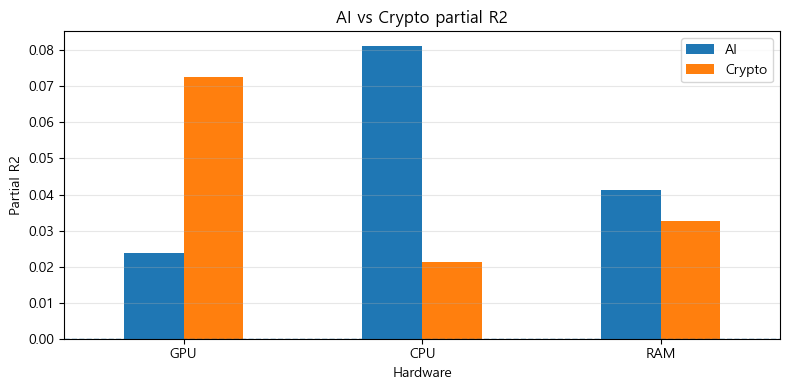

saved: output_pic\h1_final_v7\sens_bar.png


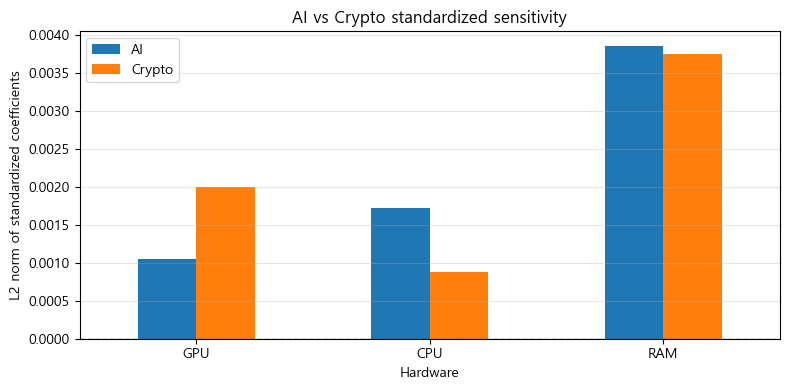

saved: output_pic\h1_final_v7\rmse_gain_bar.png


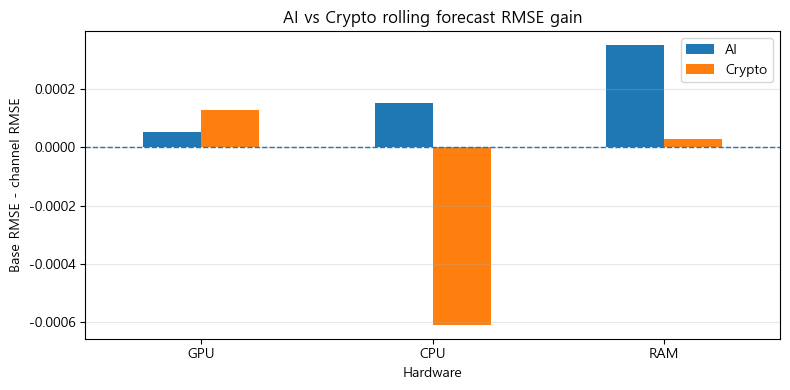

In [11]:
plot1 = main.set_index("cat")[["ai_pr2", "crypto_pr2"]].rename(columns={"ai_pr2": "AI", "crypto_pr2": "Crypto"}).loc[ORDER]
plt.figure(figsize=(8, 4))
plot1.plot(kind="bar", ax=plt.gca())
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("AI vs Crypto partial R2")
plt.xlabel("Hardware")
plt.ylabel("Partial R2")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save("pr2_bar")
plt.show()

plot2 = main.set_index("cat")[["ai_sens", "crypto_sens"]].rename(columns={"ai_sens": "AI", "crypto_sens": "Crypto"}).loc[ORDER]
plt.figure(figsize=(8, 4))
plot2.plot(kind="bar", ax=plt.gca())
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("AI vs Crypto standardized sensitivity")
plt.xlabel("Hardware")
plt.ylabel("L2 norm of standardized coefficients")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save("sens_bar")
plt.show()

plot3 = main.set_index("cat")[["ai_rmse_gain", "crypto_rmse_gain"]].rename(columns={"ai_rmse_gain": "AI", "crypto_rmse_gain": "Crypto"}).loc[ORDER]
plt.figure(figsize=(8, 4))
plot3.plot(kind="bar", ax=plt.gca())
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("AI vs Crypto rolling forecast RMSE gain")
plt.xlabel("Hardware")
plt.ylabel("Base RMSE - channel RMSE")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save("rmse_gain_bar")
plt.show()

,cat,term,coef,se,p,channel,window
0,GPU,ai_0,0.00094,0.00068,0.16381,AI,0
1,GPU,ai_12,-0.00022,0.00056,0.69215,AI,12
2,GPU,ai_38,0.00042,0.00051,0.41448,AI,38
3,GPU,crypto_0,-0.00053,0.00060,0.38147,Crypto,0
4,GPU,crypto_12,0.00185,0.00140,0.18815,Crypto,12
5,GPU,crypto_38,0.00055,0.00051,0.28466,Crypto,38
6,CPU,ai_0,-0.00067,0.00041,0.09977,AI,0
7,CPU,ai_12,0.00058,0.00064,0.36091,AI,12
8,CPU,ai_38,0.00147,0.00043,0.00064,AI,38
9,CPU,crypto_0,0.00049,0.00055,0.37249,Crypto,0


saved: output_pic\h1_final_v7\coef_gpu.png


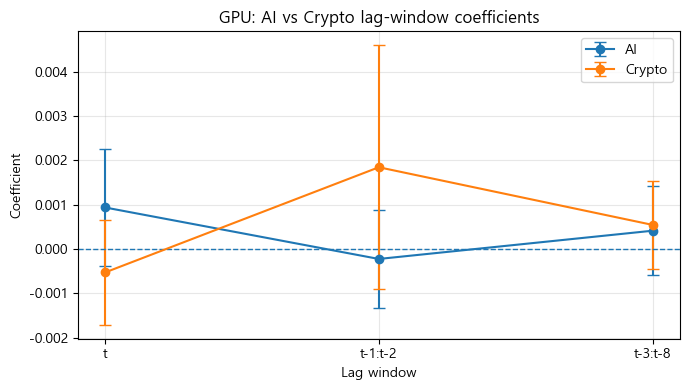

saved: output_pic\h1_final_v7\coef_cpu.png


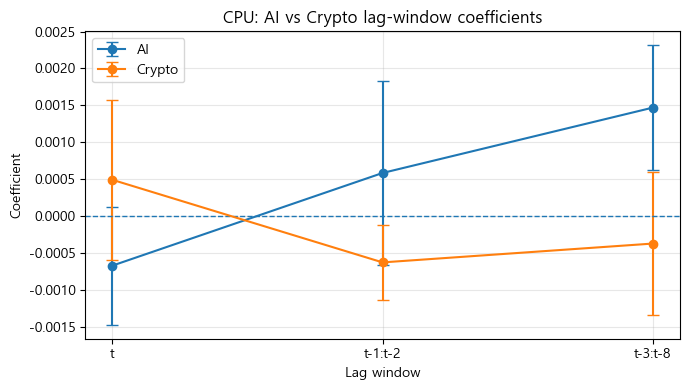

saved: output_pic\h1_final_v7\coef_ram.png


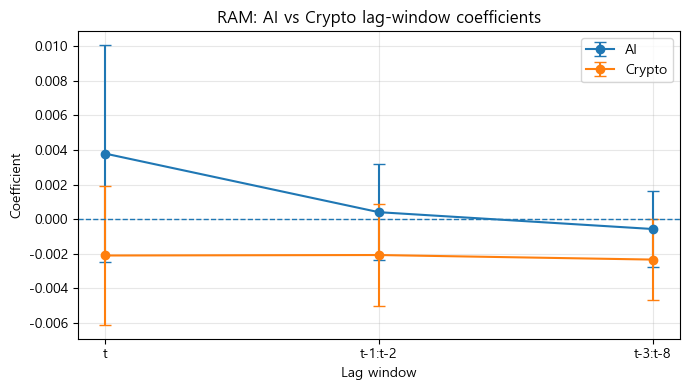

In [12]:
coef_rows = []
for cat, mod in mods.items():
    for t in TERMS:
        coef_rows.append({
            "cat": cat,
            "term": t,
            "coef": mod.params[t],
            "se": mod.bse[t],
            "p": mod.pvalues[t],
            "channel": "AI" if t in AI else "Crypto",
            "window": t.split("_", 1)[1],
        })

coef = pd.DataFrame(coef_rows)
coef.to_csv(RES / "coef.csv", index=False)
display(coef.round(5))

xmap = {"0": 0, "12": 1, "38": 2}
xlbl = {"0": "t", "12": "t-1:t-2", "38": "t-3:t-8"}

for cat in ORDER:
    d = coef[coef["cat"] == cat].copy()
    d["x"] = d["window"].map(xmap)
    plt.figure(figsize=(7, 4))
    for ch in ["AI", "Crypto"]:
        s = d[d["channel"] == ch].sort_values("x")
        plt.errorbar(s["x"], s["coef"], yerr=1.96 * s["se"], marker="o", capsize=4, label=ch)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks([0, 1, 2], [xlbl[k] for k in ["0", "12", "38"]])
    plt.title(f"{cat}: AI vs Crypto lag-window coefficients")
    plt.xlabel("Lag window")
    plt.ylabel("Coefficient")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save(f"coef_{cat.lower()}")
    plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>6. 보조 검정: Event Study</mark></b></span><br><br>

<b>[왜 보조 검정인가]</b><br>
Event study는 교수님이 말한 <b>specific economic event</b>를 보여주기에 좋다.
하지만 2024~2026 주간 표본에서 상위 10% shock week는 사건 수가 많지 않으므로, 메인 결론은 lag-window ARDL과 rolling forecast에 둔다.<br><br>

<b>[Event 정의]</b><br>
• AI event: AI shock 상위 10% 주차<br>
• Crypto event: Crypto shock 상위 10% 주차<br>
• 같은 주에 둘 다 발생한 overlap은 메인 event 비교에서 제외<br><br>

<b>[Abnormal return]</b><br>
<code>ret_h,t = a + ρ ret_h,t-1 + γ FX_t + quarter FE + error_t</code><br>
여기서 <code>error_t</code>를 abnormal return으로 보고, event 이후 <code>CAR(0,h)</code>를 계산한다.<br><br>

<b>[검정]</b><br>
AI event와 Crypto event의 CAR 차이는 permutation test로 비교한다.
</div>

,ai_raw,crypto_raw,overlap,ai_event,crypto_event
0,11,11,2,9,9


saved: output_pic\h1_final_v7\event_timeline.png


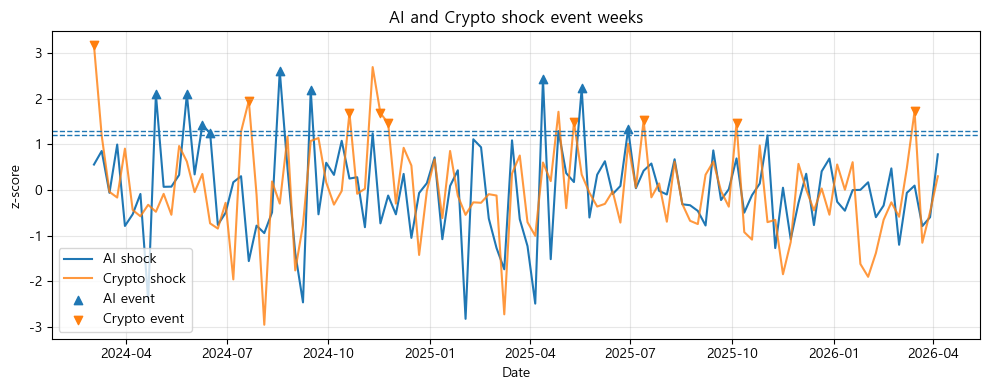

In [13]:
events = mkt[["ai", "crypto"]].dropna().copy()
ai_cut = events["ai"].quantile(Q)
cr_cut = events["crypto"].quantile(Q)

events["ai_raw"] = events["ai"] >= ai_cut
events["crypto_raw"] = events["crypto"] >= cr_cut
events["overlap"] = events["ai_raw"] & events["crypto_raw"]
events["ai_event"] = events["ai_raw"] & ~events["overlap"]
events["crypto_event"] = events["crypto_raw"] & ~events["overlap"]

ecnt = pd.DataFrame([{
    "ai_raw": int(events["ai_raw"].sum()),
    "crypto_raw": int(events["crypto_raw"].sum()),
    "overlap": int(events["overlap"].sum()),
    "ai_event": int(events["ai_event"].sum()),
    "crypto_event": int(events["crypto_event"].sum()),
}])

display(ecnt)
events.to_csv(RES / "events.csv")

plt.figure(figsize=(10, 4))
plt.plot(events.index, events["ai"], label="AI shock")
plt.plot(events.index, events["crypto"], label="Crypto shock", alpha=0.8)
plt.scatter(events.index[events["ai_event"]], events.loc[events["ai_event"], "ai"], marker="^", label="AI event")
plt.scatter(events.index[events["crypto_event"]], events.loc[events["crypto_event"], "crypto"], marker="v", label="Crypto event")
plt.axhline(ai_cut, linestyle="--", linewidth=1)
plt.axhline(cr_cut, linestyle="--", linewidth=1)
plt.title("AI and Crypto shock event weeks")
plt.xlabel("Date")
plt.ylabel("z-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
save("event_timeline")
plt.show()

,cat,h,n_ai,n_crypto,ai_car,crypto_car,ai_minus_crypto,perm_p
0,GPU,4,8,6,0.00047,-0.00077,0.00124,0.7380
1,GPU,8,8,6,0.00129,0.00237,-0.00109,0.8480
2,CPU,4,8,6,0.00024,0.00004,0.00020,0.9660
3,CPU,8,8,6,0.00132,0.00541,-0.00409,0.6240
4,RAM,4,8,6,-0.00590,-0.00672,0.00082,0.9878
5,RAM,8,8,6,-0.01637,-0.03122,0.01485,0.6290


saved: output_pic\h1_final_v7\car_gpu.png


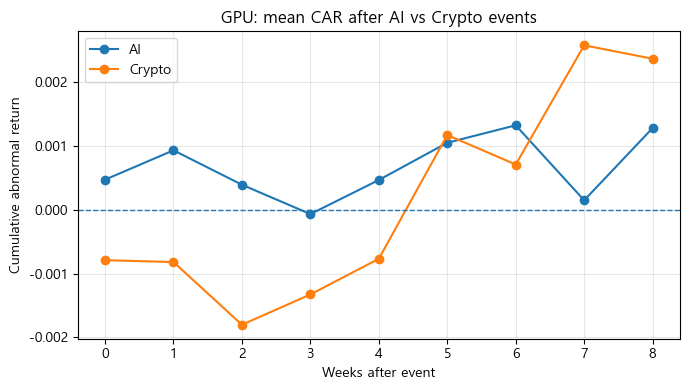

saved: output_pic\h1_final_v7\car_cpu.png


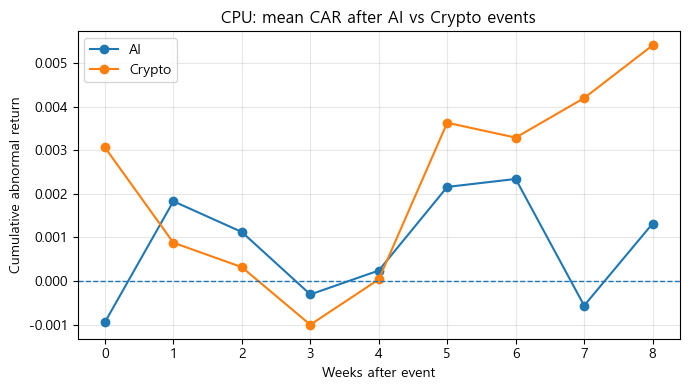

saved: output_pic\h1_final_v7\car_ram.png


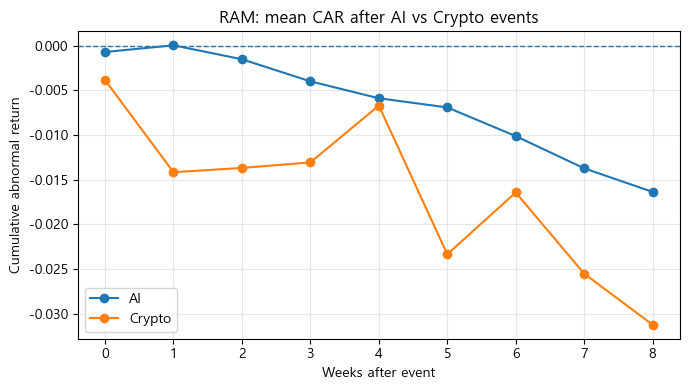

In [14]:
def abn(cat):
    d = model[model["cat"] == cat].dropna(subset=["ret"] + BASE).copy()
    mod = fit("ret ~ " + " + ".join(BASE), d)
    out = d[["date", "cat", "ret"] + BASE].copy()
    out["abn"] = mod.resid
    return out

ab = pd.concat([abn(c) for c in ORDER], ignore_index=True)
ab = ab.merge(events[["ai_event", "crypto_event"]], left_on="date", right_index=True, how="left")
ab[["ai_event", "crypto_event"]] = ab[["ai_event", "crypto_event"]].fillna(False)


def car_one(cat, max_h=8):
    d = ab[ab["cat"] == cat].sort_values("date").reset_index(drop=True)
    rows = []
    for col, lab in [("ai_event", "AI"), ("crypto_event", "Crypto")]:
        for i in d.index[d[col]]:
            for h in range(max_h + 1):
                j = i + h
                if j < len(d):
                    rows.append({"cat": cat, "event": lab, "event_date": d.loc[i, "date"], "h": h, "car": d.loc[i:j, "abn"].sum()})
    return pd.DataFrame(rows)


def perm(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    obs = a.mean() - b.mean()
    pool = np.r_[a, b]
    rng = np.random.default_rng(SEED)
    vals = np.empty(B)
    for i in range(B):
        p = rng.permutation(pool)
        vals[i] = p[:len(a)].mean() - p[len(a):].mean()
    return obs, np.mean(np.abs(vals) >= abs(obs))

car = pd.concat([car_one(c) for c in ORDER], ignore_index=True)
rows = []
for cat in ORDER:
    for h in [4, 8]:
        d = car[(car["cat"] == cat) & (car["h"] == h)]
        a = d[d["event"] == "AI"]["car"]
        c = d[d["event"] == "Crypto"]["car"]
        if len(a) and len(c):
            diff, p = perm(a, c)
            rows.append({"cat": cat, "h": h, "n_ai": len(a), "n_crypto": len(c), "ai_car": a.mean(), "crypto_car": c.mean(), "ai_minus_crypto": diff, "perm_p": p})

car_sum = pd.DataFrame(rows)
display(car_sum.round(5))
car.to_csv(RES / "car_long.csv", index=False)
car_sum.to_csv(RES / "car.csv", index=False)

path = car.groupby(["cat", "event", "h"])["car"].mean().reset_index()
for cat in ORDER:
    plt.figure(figsize=(7, 4))
    for ev in ["AI", "Crypto"]:
        s = path[(path["cat"] == cat) & (path["event"] == ev)]
        plt.plot(s["h"], s["car"], marker="o", label=ev)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{cat}: mean CAR after AI vs Crypto events")
    plt.xlabel("Weeks after event")
    plt.ylabel("Cumulative abnormal return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save(f"car_{cat.lower()}")
    plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>7. 강건성 검정: proxy 정의 변경</mark></b></span><br><br>

<b>[Robustness 1]</b><br>
AI shock을 raw NVDA가 아니라 <b>NASDAQ/SOX를 제거한 residualized NVDA</b>로 변경한다.<br><br>

<b>[Robustness 2]</b><br>
Crypto shock을 BTC 단독이 아니라 <b>BTC+ETC 공통요인 Crypto PC1</b>으로 변경한다.<br><br>

<b>[Robustness 3]</b><br>
BTC-KRW와 FX 통제가 겹칠 수 있으므로, Crypto shock을 <b>FX-adjusted BTC</b>로 변경해도 방향이 유지되는지 확인한다.<br><br>

<b>[해석]</b><br>
강건성 검정에서는 p-value 하나보다 <b>partial R² winner와 sensitivity winner의 방향이 유지되는지</b>를 중심으로 본다.
</div>

In [16]:
def run_alt(ai_col, cr_col, label):
    f = make_feat(ai_col, cr_col)

    d0 = ret.merge(f[["fx_ret"] + TERMS], left_on="date", right_index=True, how="inner")
    d0 = d0.sort_values(["cat", "date"]).copy()

    d0["ret_l1"] = d0.groupby("cat")["ret"].shift(1)

    # Quarter fixed effects: q1 is the baseline
    d0["q"] = d0["date"].dt.quarter
    for k in [2, 3, 4]:
        d0[f"q{k}"] = (d0["q"] == k).astype(int)

    rows = []
    for cat in ORDER:
        d = d0[d0["cat"] == cat].dropna(subset=["ret"] + FULL).copy()

        ff = "ret ~ " + " + ".join(FULL)
        fna = "ret ~ " + " + ".join(BASE + CR)
        fnc = "ret ~ " + " + ".join(BASE + AI)

        mf = fit(ff, d)
        mna = fit(fna, d)
        mnc = fit(fnc, d)

        ai_F, ai_p = wald(mf, AI)
        cr_F, cr_p = wald(mf, CR)

        ai_coef = mf.params[AI]
        cr_coef = mf.params[CR]

        rows.append({
            "test": label,
            "cat": cat,
            "n": len(d),
            "ai_p": ai_p,
            "crypto_p": cr_p,
            "ai_pr2": pr2(mf, mna),
            "crypto_pr2": pr2(mf, mnc),
            "ai_sens": float(np.sqrt((ai_coef ** 2).sum())),
            "crypto_sens": float(np.sqrt((cr_coef ** 2).sum())),
        })

    return pd.DataFrame(rows)

rob = pd.concat([
    run_alt("ai_resid_z", "crypto", "resid_nvda_vs_btc"),
    run_alt("ai", "crypto_pc1", "nvda_vs_crypto_pc1"),
    run_alt("ai", "crypto_fxadj", "nvda_vs_btc_fxadj"),
    run_alt("ai_resid_z", "crypto_pc1", "resid_nvda_vs_crypto_pc1"),
], ignore_index=True)

rob["r2_win"] = [win(a, c) for a, c in zip(rob["ai_pr2"], rob["crypto_pr2"])]
rob["sens_win"] = [win(a, c) for a, c in zip(rob["ai_sens"], rob["crypto_sens"])]
rob["judgment"] = np.where(rob["r2_win"] == rob["sens_win"], rob["r2_win"], "Mixed")

display(rob.round(5))
rob.to_csv(RES / "robustness.csv", index=False)

,test,cat,n,ai_p,crypto_p,ai_pr2,crypto_pr2,ai_sens,crypto_sens,r2_win,sens_win,judgment
0,resid_nvda_vs_btc,GPU,98,0.73531,0.39691,0.03165,0.07455,0.00120,0.00194,Crypto,Crypto,Crypto
1,resid_nvda_vs_btc,CPU,98,0.62180,0.53137,0.01297,0.00692,0.00062,0.00046,AI,AI,AI
2,resid_nvda_vs_btc,RAM,98,0.28320,0.22413,0.08447,0.01716,0.00602,0.00255,AI,AI,AI
3,nvda_vs_crypto_pc1,GPU,98,0.59033,0.58202,0.02401,0.05906,0.00109,0.00181,Crypto,Crypto,Crypto
4,nvda_vs_crypto_pc1,CPU,98,0.00096,0.17166,0.07885,0.02681,0.00165,0.00096,AI,AI,AI
5,nvda_vs_crypto_pc1,RAM,98,0.61466,0.06139,0.03965,0.04061,0.00386,0.00421,Crypto,Crypto,Crypto
6,nvda_vs_btc_fxadj,GPU,98,0.56931,0.55217,0.02369,0.06542,0.00107,0.00190,Crypto,Crypto,Crypto
7,nvda_vs_btc_fxadj,CPU,98,0.00041,0.06331,0.08138,0.02401,0.00171,0.00094,AI,AI,AI
8,nvda_vs_btc_fxadj,RAM,98,0.56740,0.07302,0.04249,0.03251,0.00394,0.00377,AI,AI,AI
9,resid_nvda_vs_crypto_pc1,GPU,98,0.74198,0.48049,0.03059,0.05992,0.00119,0.00175,Crypto,Crypto,Crypto


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>8. 최종 해석표</mark></b></span><br><br>

<b>[해석 순서]</b><br>
1. <b>Partial R²</b>가 더 큰 쪽을 먼저 본다. 이는 상대 채널을 통제한 뒤 추가 설명력이 어느 쪽에서 더 큰지를 직접 보여준다.<br>
2. <b>Standardized sensitivity</b>가 같은 방향인지 확인한다. 이는 충격 1표준편차 기준 회귀 민감도이다.<br>
3. <b>Rolling forecast RMSE gain</b>은 보조 진단이다. 양수일 때만 base 대비 예측오차를 줄였다고 해석한다.<br>
4. Partial R²와 sensitivity가 같은 방향이면 해당 채널을 더 강한 설명 채널로 해석한다. RMSE와 event study는 이를 보조한다.<br>
5. 기준이 갈리면 <b>Mixed</b>로 보고, 한쪽이 지배적이라고 말하지 않는다.<br><br>

<b>[발표 문장 원칙]</b><br>
결과가 애매하면 “AI가 원인이다” 또는 “Crypto가 원인이다”라고 말하지 않고,
<mark>관측된 주간 수익률 기준으로 어느 채널의 상대 설명력과 민감도가 더 컸는지</mark>만 말한다.
</div>

In [17]:
core_cols = ["r2_win", "sens_win"]
all_cols = ["r2_win", "sens_win", "rmse_win"]


def vote(row):
    if row["r2_win"] == row["sens_win"] and row["r2_win"] != "Mixed":
        return row["r2_win"]
    return "Mixed"


def support(row):
    a = sum(row[c] == "AI" for c in all_cols)
    c = sum(row[c] == "Crypto" for c in all_cols)
    if row["judgment"] == "Mixed":
        return "Mixed"
    if row["judgment"] == "AI" and a >= 2:
        return "Core+Diagnostic"
    if row["judgment"] == "Crypto" and c >= 2:
        return "Core+Diagnostic"
    return "Core only"

main["judgment"] = main.apply(vote, axis=1)
main["support_level"] = main.apply(support, axis=1)

final = main[[
    "cat", "n", "ai_p", "crypto_p", "ai_pr2", "crypto_pr2",
    "ai_sens", "crypto_sens", "ai_rmse_gain", "crypto_rmse_gain",
    "ai_minus_crypto_loss", "loss_p", "ai_cum", "crypto_cum",
    "r2_win", "sens_win", "rmse_win", "judgment", "support_level"
]].copy()

final["sentence"] = final["judgment"].map({
    "AI": "AI channel has stronger in-sample explanatory power and standardized sensitivity.",
    "Crypto": "Crypto channel has stronger in-sample explanatory power and standardized sensitivity.",
    "Mixed": "Evidence is mixed; do not claim a single dominant channel.",
})

display(final.round(5))
final.to_csv(RES / "final.csv", index=False)

print("saved tables:", RES)
print("saved figures:", PIC)


,cat,n,ai_p,crypto_p,ai_pr2,crypto_pr2,ai_sens,crypto_sens,ai_rmse_gain,crypto_rmse_gain,ai_minus_crypto_loss,loss_p,ai_cum,crypto_cum,r2_win,sens_win,rmse_win,judgment,support_level,sentence
0,GPU,98,0.57467,0.48471,0.02391,0.07260,0.00105,0.00200,0.00005,0.00013,0.00000,0.56471,0.00113,0.00187,Crypto,Crypto,Crypto,Crypto,Core+Diagnostic,Crypto channel has stronger in-sample explanat...
1,CPU,98,0.00055,0.08236,0.08121,0.02124,0.00172,0.00088,0.00015,-0.00061,-0.00001,0.01153,0.00138,-0.00051,AI,AI,AI,AI,Core+Diagnostic,AI channel has stronger in-sample explanatory ...
2,RAM,98,0.56524,0.09477,0.04122,0.03277,0.00386,0.00376,0.00035,0.00003,-0.00002,0.34563,0.00364,-0.00650,AI,AI,AI,AI,Core+Diagnostic,AI channel has stronger in-sample explanatory ...


saved tables: outputs\h1_final_v7
saved figures: output_pic\h1_final_v7
